# 91 - Inside the Latent Code

**Section:** Autoencoders | **Prereqs:** `Autoencoders/AE_for_Occlusion.ipynb` | **Next:** `Autoencoders/AE_with_Tied_Weights.ipynb`

What is actually *in* the bottleneck? This notebook trains a 15-unit autoencoder
and then examines the code: its activation distribution, and how it compares
against PCA - the classic linear dimensionality reduction.

**Autoencoder vs PCA.** A linear autoencoder with a squared-error loss learns the
same subspace PCA does. The non-linear one here can do better: it can curve, so it
captures structure PCA cannot. The scree plot compares how much variance each
approach packs into its first components.

**What to look for in the scatter plots.** Project both the raw pixels and the
latent code onto their first two principal components, coloured by digit. If the
digit clusters are better separated in the *code* projection, the autoencoder has
organised the data by content - even though it never saw a single label. That is
representation learning, and it is why the encoder is worth transferring
(`Transfer Learning/Pretraining_with_AutoEncoders.ipynb`).

**The activation histogram matters too.** With ReLU on the latent, expect a large
spike at exactly zero - most units are off for any given image, so the code is
naturally sparse. If a unit is zero for *every* image it is dead capacity, and the
bottleneck is effectively smaller than it looks.

**784 numbers to 15 and back**, with recognisable digits coming out, is the
concrete demonstration that images live on a far lower-dimensional manifold than
their pixel count suggests.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

from torchvision.datasets import MNIST
from torchvision.transforms import ToTensor

from sklearn.decomposition import PCA

In [4]:
data = MNIST(
    root='./data',        # Directory to store the dataset
    train=True,           # Load the training set
    download=True,
    transform = ToTensor()
)

test_data =  MNIST(
    root='./data',        # Directory to store the dataset
    train=False,           # Load the training set
    download=True,
    transform = ToTensor()
)

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.57MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 131kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.24MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 10.0MB/s]


In [5]:
# MNIST flattened to 784-vectors and scaled to [0,1] with MinMaxScaler.
# The [0,1] range matters: the decoder ends in sigmoid, whose range is exactly
# [0,1]. Match the output activation to the target's range.
def makeDataset():

  data_tensor = data.data.view(-1, 784)
  labels_tensor = data.targets


  from sklearn.preprocessing import MinMaxScaler

  scaler = MinMaxScaler()

  data_subset = scaler.fit_transform(data_tensor)

  train_data = torch.tensor(data_subset, dtype=torch.float, device='cuda')
  train_label = torch.tensor(labels_tensor, dtype=torch.long, device='cuda')


  return train_data, train_label

In [6]:
train_data, train_label = makeDataset()

/tmp/ipython-input-289672233.py:14: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  train_label = torch.tensor(labels_tensor, dtype=torch.long, device='cuda')


In [7]:
# 784 -> 250 -> 15 -> 250 -> 784. A 15-unit bottleneck: 52x compression.
# forward returns BOTH the reconstruction and `codex`, the latent activations -
# the pattern for inspecting an internal representation.
class model(nn.Module):
  def __init__(self):
    super().__init__()

    self.input_layer = nn.Linear(784, 250)

    self.fc1 = nn.Linear(250,15)

    self.fc2 = nn.Linear(15,250)

    self.output_layer = nn.Linear(250,784)


  def forward(self,x):

    x = F.relu(self.input_layer(x))

    codex = F.relu(self.fc1(x))

    x = F.relu(self.fc2(codex))

    return  F.sigmoid(self.output_layer(x)), codex

In [8]:
# An untrained forward pass through the whole training set.
AutoEncoder = model().to('cuda')

output,codex = AutoEncoder(train_data)

In [9]:
output[0].shape, output[1].shape

(torch.Size([784]), torch.Size([784]))

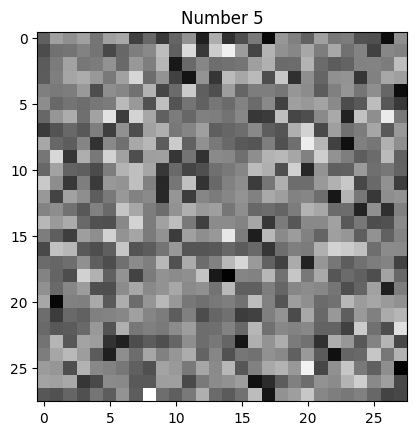

In [10]:
# Random-weight output.
plt.imshow(output[0].reshape(28,28).detach().cpu(),cmap='gray');
plt.title(f'Number {str(train_label[0].item())}');

In [11]:
# Note the manual batching: a random permutation each epoch, then contiguous
# slices of it. Equivalent to a shuffled DataLoader, written out by hand.
# The slice runs batchi*bs to (batchi+1)*bs - starting at (batchi-1)*bs would
# make the first iteration index -32..0, silently wrapping around to the end of
# the array.
def train_model():


  AutoEncoder = model().to('cuda')

  epochs = 5
  lr = 0.001

  lossFunc =  nn.MSELoss()
  optimizer = torch.optim.Adam(AutoEncoder.parameters(), lr=lr)

  train_acc = []
  losses = []

  bs = 32
  noBatches = int(train_data.shape[0]/bs)


  for i in range(epochs):

    randidx = np.random.permutation(train_data.shape[0]).astype(int)

    batch_losses = []

    for batchi in range(noBatches):

      samps2use = range(batchi*bs,(batchi+1)*bs)

      X = train_data[randidx[samps2use],:]

      AutoEncoder.train()

      yhat,_ = AutoEncoder(X)
      loss = lossFunc(yhat,X) # We compare the loss with the inital input
      batch_losses.append(loss.item())


      optimizer.zero_grad()
      loss.backward()
      optimizer.step()

    losses.append(np.mean(batch_losses) )
  return losses,AutoEncoder

In [ ]:
losses , AutoEncoder = train_model()

In [ ]:
# Reconstruction loss over 5 epochs.
plt.plot(losses);

# Checking the latent code now:

In [ ]:
# Encode the entire training set. `latent` is (60000, 15) - the autoencoder's
# complete description of MNIST.
yhat, latent = AutoEncoder(train_data)

In [ ]:
# Two views of the code.
# LEFT: the activation histogram. With ReLU expect a large spike at exactly zero -
# most units are off for any given image, so the code is naturally sparse. A unit
# that is zero for EVERY image is dead capacity.
# RIGHT: all activations as an image, rows = images, columns = latent units.
# Vertical stripes mean some units are consistently more active than others;
# horizontal structure means different digits use different units.
print(yhat.shape)
print(latent.shape)
fig,ax = plt.subplots(1,2,figsize=(15,5))

ax[0].hist(latent.flatten().detach().cpu(),100)
ax[0].set_xlabel('Latent activation value')
ax[0].set_ylabel('Count')
ax[0].set_title('Distribution of latent units activations')

ax[1].imshow(latent.detach().cpu(),aspect='auto',vmin=0,vmax=10)
ax[1].set_xlabel('Latent node')
ax[1].set_ylabel('Image number')
ax[1].set_title('All latent activations')

plt.show();

In [ ]:
# PCA scree plots for the raw data and for the code.
# PCA finds the directions of greatest variance - the linear version of what the
# autoencoder does non-linearly. The code's variance is concentrated in fewer
# components, because the autoencoder has already removed the redundancy.

# compute and fit the PCA
pcaData = PCA(n_components=15).fit(train_data.cpu()) # 15 components to match latent, but it's just to speed computation time
pcaCode = PCA().fit(latent.detach().cpu())


plt.plot(100*pcaData.explained_variance_ratio_,'s-',label='Data PCA')
plt.plot(100*pcaCode.explained_variance_ratio_,'o-',label='Code PCA')
plt.xlabel('Components')
plt.ylabel('Percent variance explained')
plt.title('PCA scree plot')
plt.legend()
plt.show()

In [ ]:
# THE INTERESTING PLOT: the first two principal components of the raw pixels
# (left) against those of the latent code (right), coloured by digit.
# If the clusters separate better on the right, the autoencoder organised the
# data by CONTENT - and it did so without ever seeing a label.
# That is why an autoencoder's encoder is worth reusing as a feature extractor.
scoresData = pcaData.fit_transform(train_data.cpu().detach())
scoresCode = pcaCode.fit_transform(latent.detach().cpu())

# plot the data separately per number
fig,ax = plt.subplots(1,2,figsize=(15,5))

for lab in range(10):
  ax[0].plot(scoresData[train_label.cpu().detach()==lab,0],scoresData[train_label.cpu().detach()==lab,1],'o',markersize=3,alpha=.4)
  ax[1].plot(scoresCode[train_label.cpu().detach()==lab,0],scoresCode[train_label.cpu().detach()==lab,1],'o',markersize=3,alpha=.4)

for i in range(2):
  ax[i].set_xlabel('PC1 projection')
  ax[i].set_ylabel('PC2 projection')
  ax[i].legend(range(10))

ax[0].set_title('PCA of data')
ax[1].set_title('PCA of latent code')
plt.show()

In [ ]:
# One image in three representations: as a picture, as 784 pixel intensities,
# and as 15 latent activations.
# Those 15 numbers are enough to rebuild a recognisable digit - which is the
# concrete evidence that images live on a far lower-dimensional manifold than
# their pixel count suggests.
fig,ax = plt.subplots(1,3,figsize=(15,3))

ax[0].imshow(train_data.cpu().detach()[0,:].view(28,28),cmap='gray')

ax[1].plot(train_data.cpu().detach()[0,:],'ks')
ax[1].set_xlabel('Pixels (vectorized)')
ax[1].set_ylabel('Intensity value')

ax[2].plot(latent[0,:].detach().cpu(),'ks')
ax[2].set_xlabel('Latent units')
ax[2].set_ylabel('Activation (a.u.)')

plt.show()